# Section 7.1 Experiment 1

- `n` variation experiment
- saves raw/summary CSV outputs and the original metric/runtime figures
- also renders the 19 timing-breakdown plots and the runtime-composition figure from the same notebook

In [1]:
from pathlib import Path
import sys
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "reference_1_section7_1":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name == "experiments":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.common import default_exp1_config, default_output_dir, run_and_save_experiment1
from src.common import compute_global_metric_limits, render_all_section7_visualizations

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)


In [2]:
cfg = default_exp1_config()
show_progress = True
plot_basics = True
detailed_timing = True
outdir = default_output_dir("exp1")

cfg

Exp1Config(n_values=[200, 400, 600, 800, 1000, 1200], K=3, K_prime=3, alpha_n=0.2, lam=0.5, q=2, r=10, p=0.7, reps=20, seed=2026)

In [3]:
outputs = run_and_save_experiment1(
    cfg=cfg,
    outdir=outdir,
    show_progress=show_progress,
    detailed_timing=detailed_timing,
    plot_basics=plot_basics,
)

outputs.to_frame()

\ [##################################]  360/ 360 (100.0%) | n=1200 rep=20/20 method=Non-random        | elapsed=01:25 eta=00:00


,exp_key,label,outdir,raw_csv,summary_csv,timing_raw_csv,timing_summary_csv,metrics_png,runtime_png,raw_rows,summary_rows
0,exp1,Exp1 (n variation),/Users/eomjeonghyeon/Documents/github_project/...,/Users/eomjeonghyeon/Documents/github_project/...,/Users/eomjeonghyeon/Documents/github_project/...,/Users/eomjeonghyeon/Documents/github_project/...,/Users/eomjeonghyeon/Documents/github_project/...,/Users/eomjeonghyeon/Documents/github_project/...,/Users/eomjeonghyeon/Documents/github_project/...,360,18


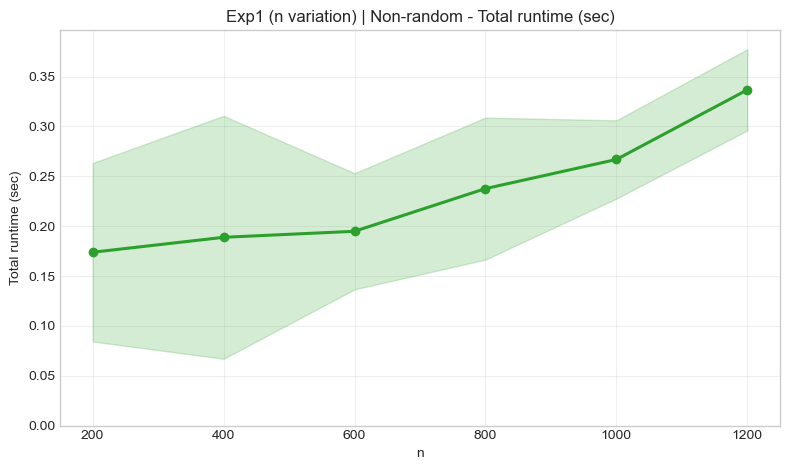

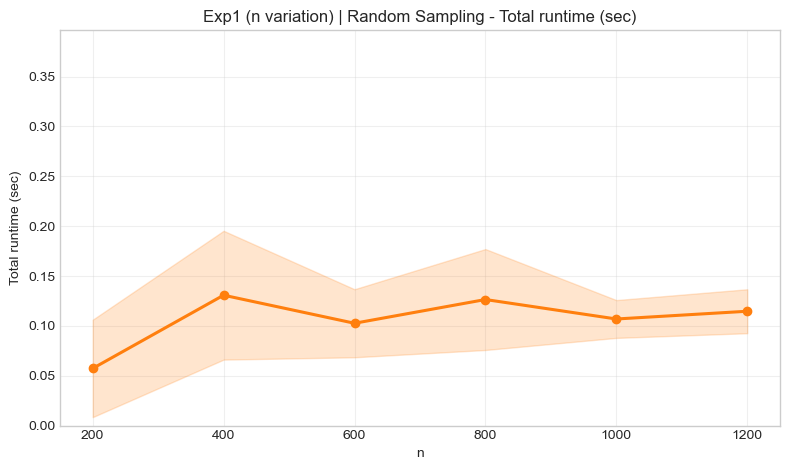

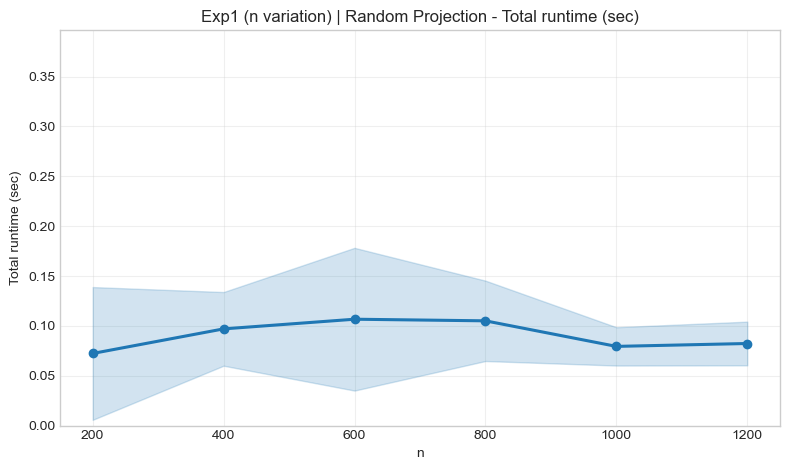

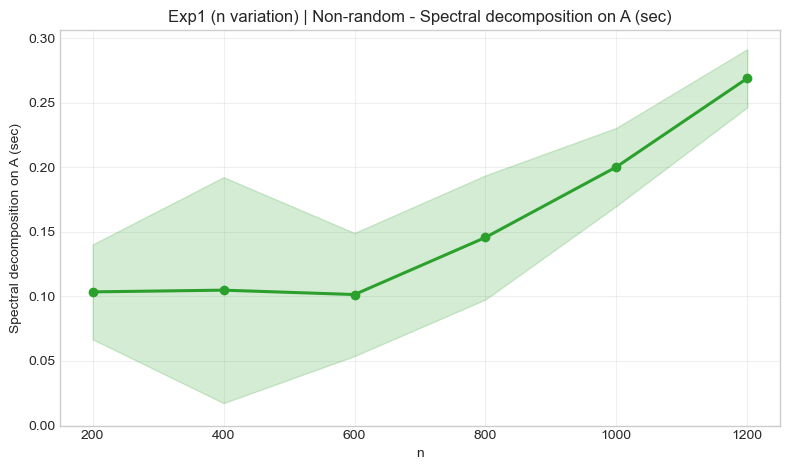

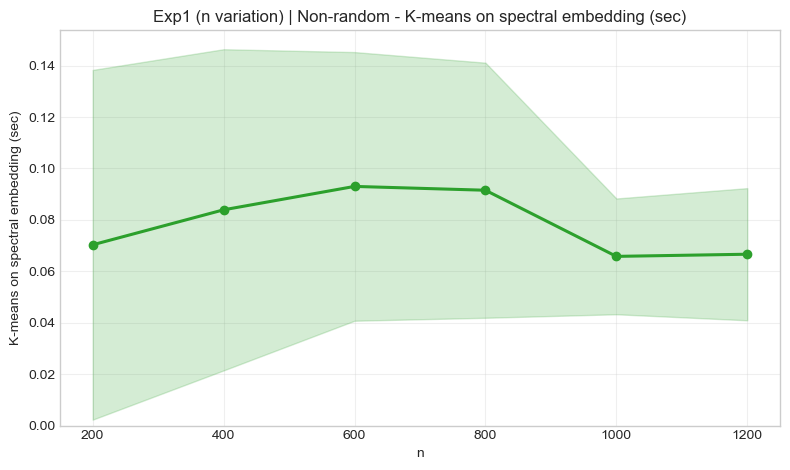

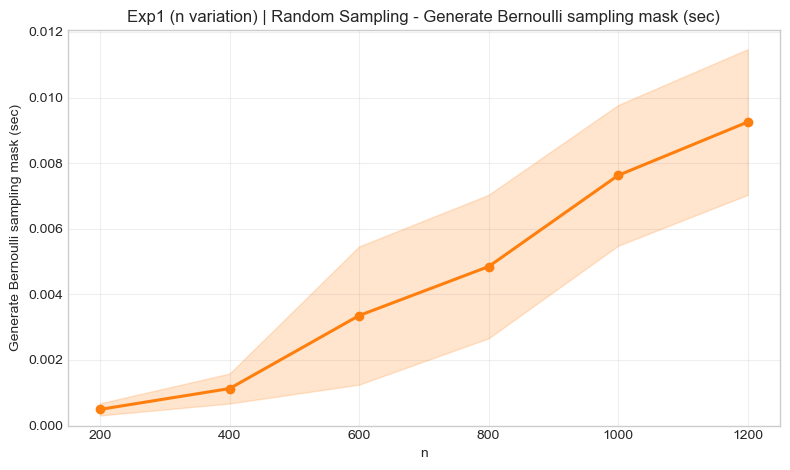

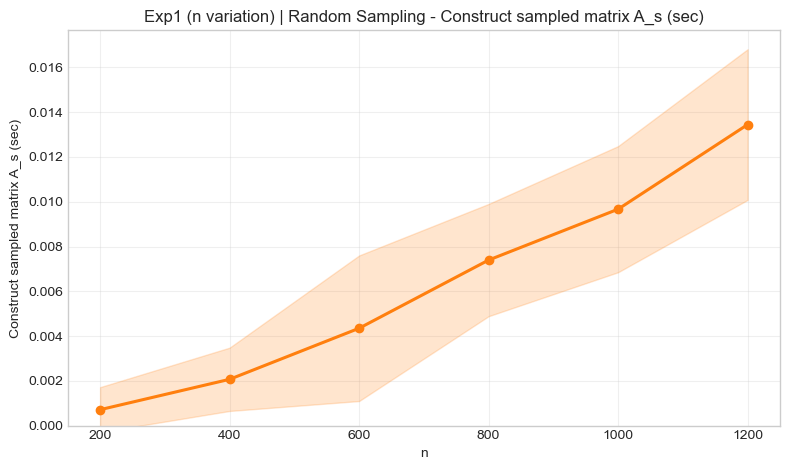

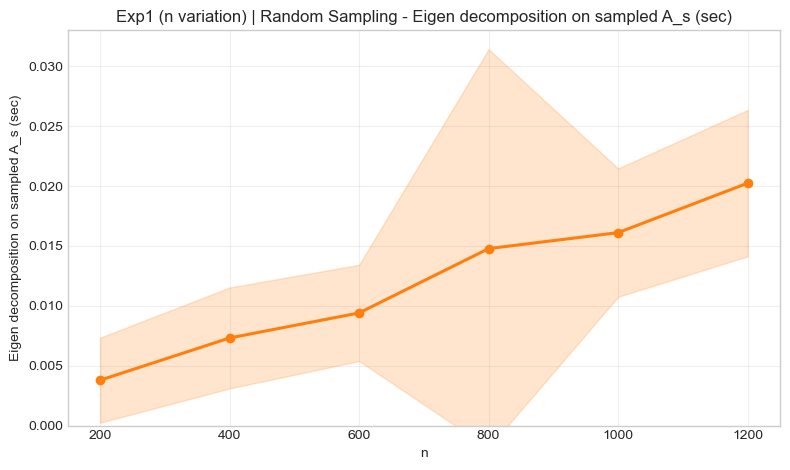

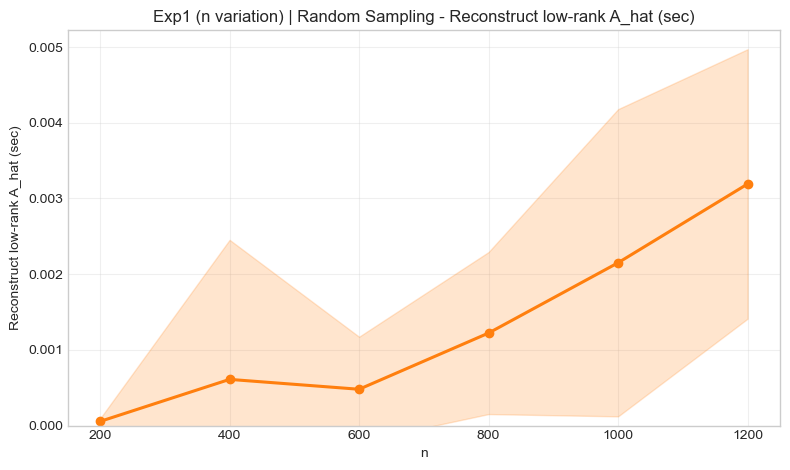

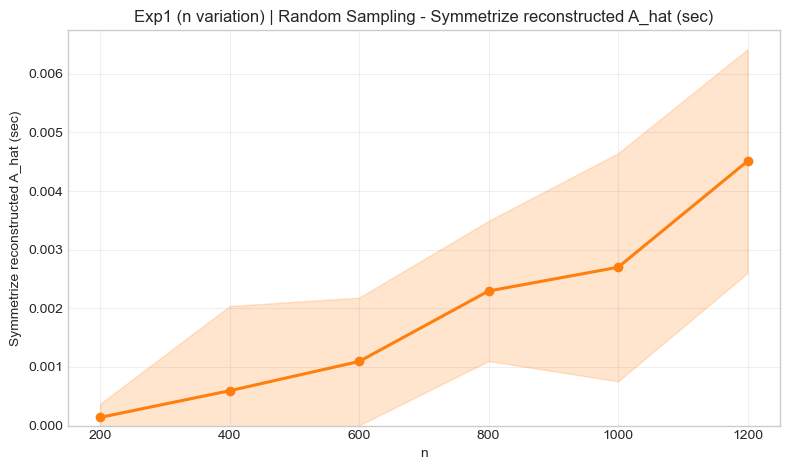

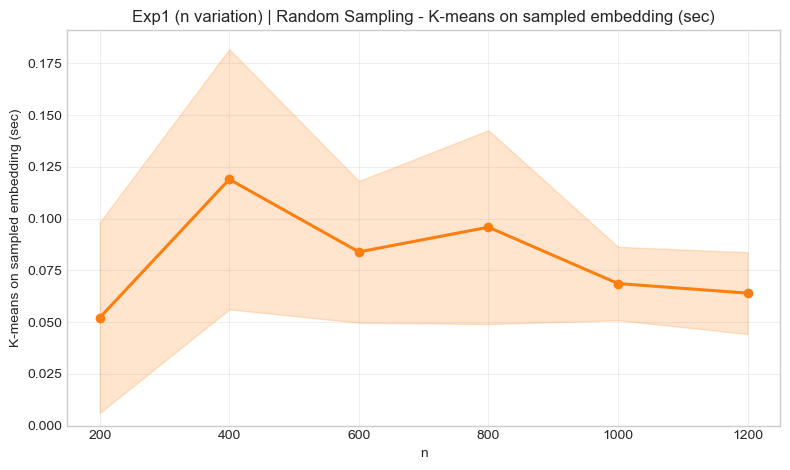

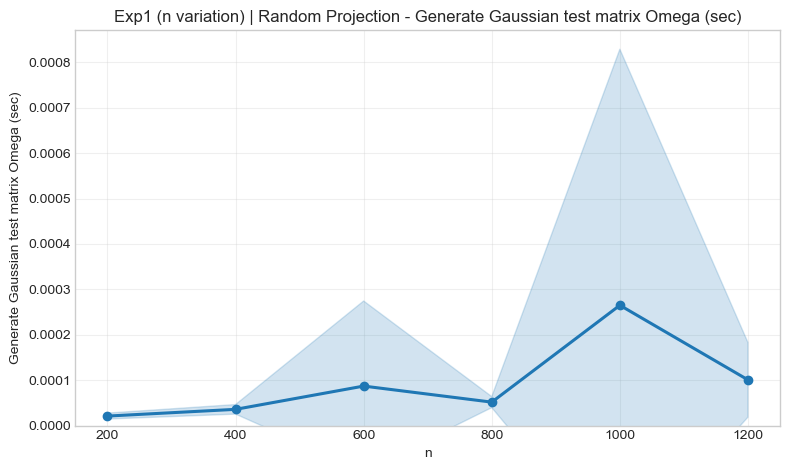

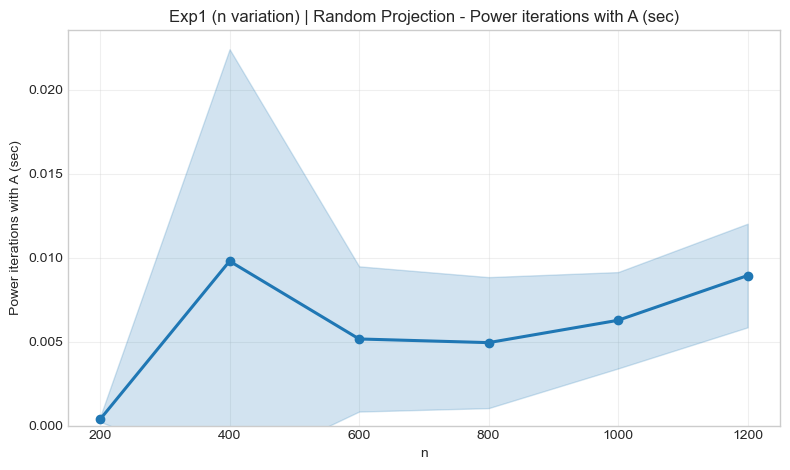

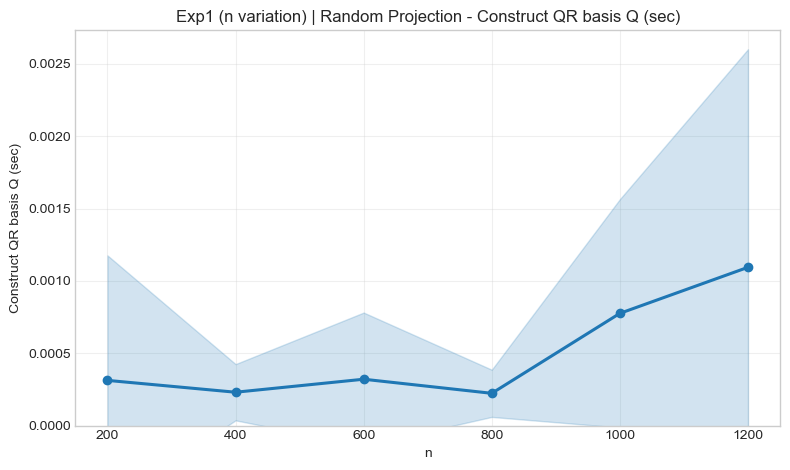

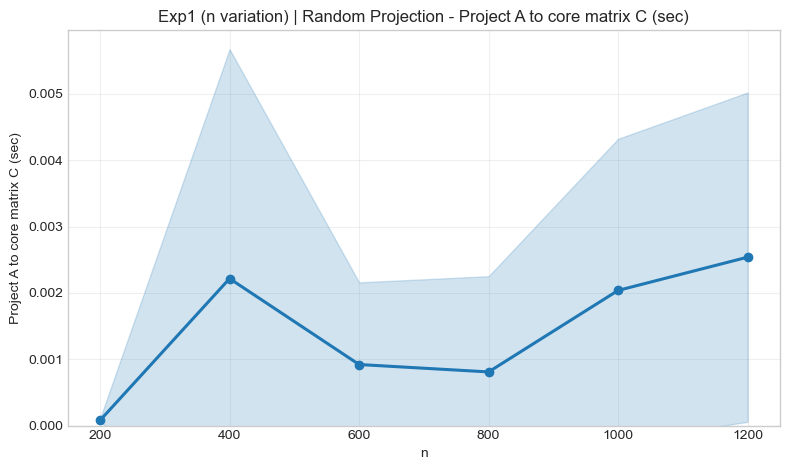

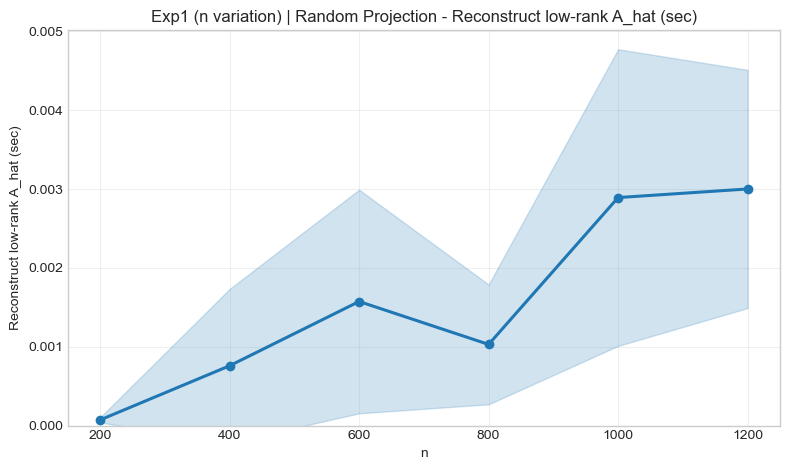

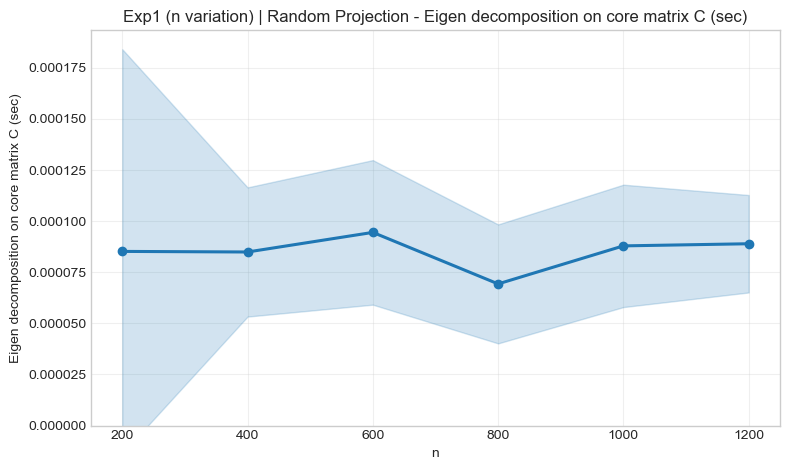

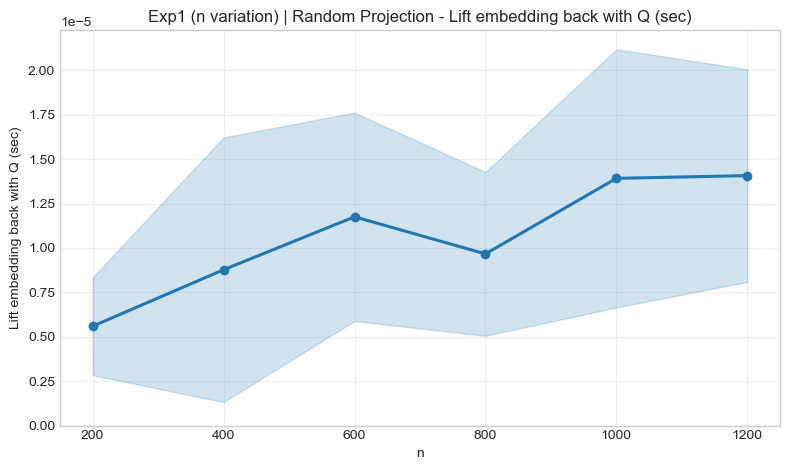

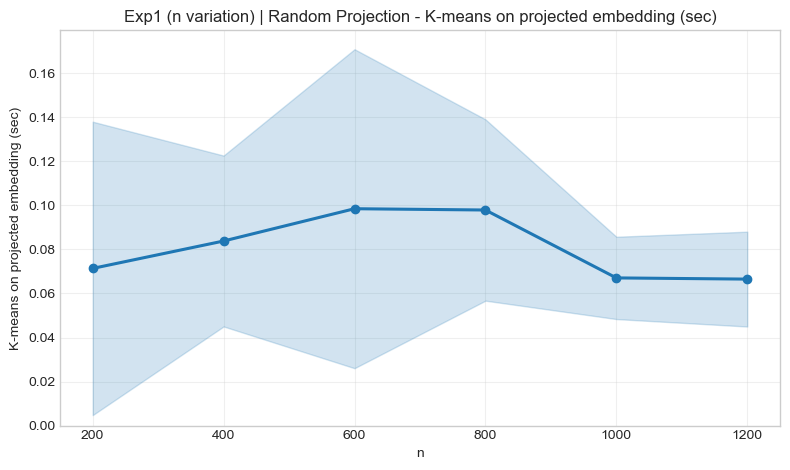

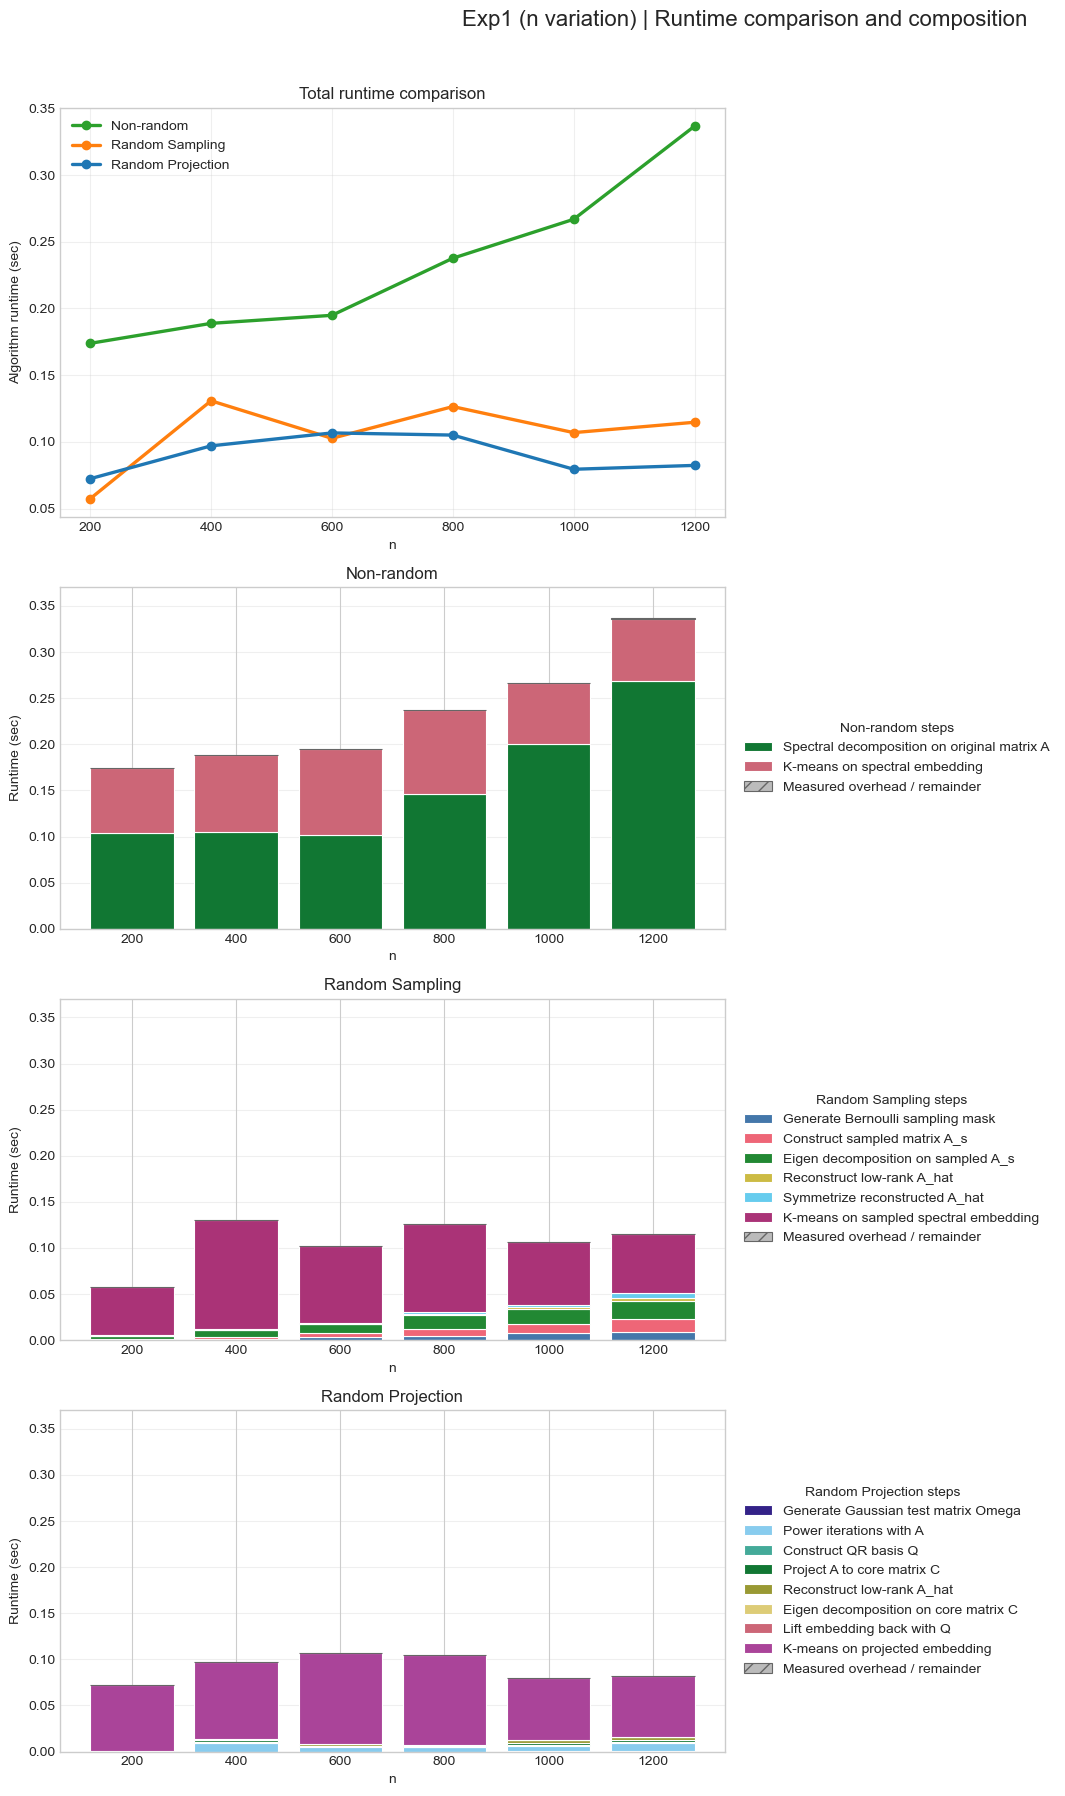

In [4]:
global_limits = compute_global_metric_limits()
breakdown_result, composition_result = render_all_section7_visualizations(
    exp_key="exp1",
    summary_path=outputs.timing_summary_csv,
    global_limits=global_limits,
)


In [5]:
breakdown_result.overall_table.round(6)

,n,method,time_sec_mean,time_sec_std
0,200,Non-random,0.173834,0.089517
1,200,Random Projection,0.072332,0.066579
2,200,Random Sampling,0.057307,0.048848
3,400,Non-random,0.188811,0.121833
4,400,Random Projection,0.096975,0.036939
5,400,Random Sampling,0.130752,0.064591
6,600,Non-random,0.194845,0.058257
7,600,Random Projection,0.106672,0.071576
8,600,Random Sampling,0.102614,0.034118
9,800,Non-random,0.237645,0.071198
